## TP2 - Visión por Computadora 1

### Objetivo:
Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las
cámaras digitales modernas. El video a procesar será: “focus_video.mov”.



1) Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper "Image
Sharpness Measure for Blurred Images in Frequency Domain“ y realizar tres experimentos: 

    1) Medición sobre todo el frame.

Primero implementamos el algoritmo FM (Frequency Domain Image Blur Measure) para medir la calidad de la imagen (Messure quality 1mage) del paper:

In [133]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

def image_quality_measure(image):
    """
    Calcula la métrica de calidad de la imagen
    FM (Frequency Domain Image Blur Measure) descrita en:
    'Image Sharpness Measure for Blurred Images in Frequency Domain'

    Parámetros:
        image: imagen en escala de grises

    Retorna:
        FM: float — métrica de nitidez
    """
    # Calcular la Transformada de Fourier 2D
    F = np.fft.fft2(image)
    
    # Centrar el espectro
    Fc = np.fft.fftshift(F)
    
    # valor absoluto
    AF = np.abs(Fc)

    # Encontrar el valor máximo
    M = AF.max()

    # Calcular el umbral
    thres = M / 1000.0

    # Contar pixeles mayores al umbral
    TH = np.sum(AF > thres)

    # Calcular la métrica de calidad
    FM = TH / image.size
    return FM

Ahora definimos funciones para cargar el video y procesar los frames para calcular la métrica de calidad por frame, y para mostrar los resultados.

In [134]:
def process_video(video_path):
    """
    Procesa un video para calcular la métrica para cada frame.
    
    Args:
        video_path: Ruta al archivo de video
        
    Returns:
        tuple: (valores_nitidez, num_frames)
    """
    cap = cv2.VideoCapture(video_path)
    
    measure_values = []
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    for _ in tqdm(range(frame_count), desc="Procesando frames"):
        ret, frame = cap.read()
        if not ret:
            break
            
        # Convertir a escala de grises
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Calcular métrica de nitidez
        sharpness = image_quality_measure(gray)
        measure_values.append(sharpness)
    
    cap.release()
    return measure_values, frame_count

def plot_results(measure_values):
    """
    Grafica los resultados del análisis de nitidez.
    """
    plt.figure(figsize=(14, 6))
    
    # Gráfico de valores de nitidez
    plt.subplot(1, 2, 1)
    plt.plot(measure_values, 'b-')
    plt.title('Métrica FM por Frame')
    plt.xlabel('Número de Frame')
    plt.ylabel('Valor de la métrica FM')
    plt.grid(True)
    
    # Histograma de valores de nitidez
    plt.subplot(1, 2, 2)
    plt.hist(measure_values, bins=30, alpha=0.7, color='green')
    plt.title('Distribución de Valores de FM')
    plt.xlabel('Valor de FM')
    plt.ylabel('Frecuencia')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas
    max_idx = np.argmax(measure_values)
    min_idx = np.argmin(measure_values)
    print(f"Frame más nítido: {max_idx} (valor: {measure_values[max_idx]:.6f})")
    print(f"Frame más borroso: {min_idx} (valor: {measure_values[min_idx]:.6f})")
    print(f"Nitidez promedio: {np.mean(measure_values):.6f} ± {np.std(measure_values):.6f}")


Ejecución y resultados:

Procesando video para calcular métricas de nitidez...


Procesando frames:   0%|          | 0/171 [00:00<?, ?it/s]


Resultados del análisis de nitidez:
Total de frames procesados: 171


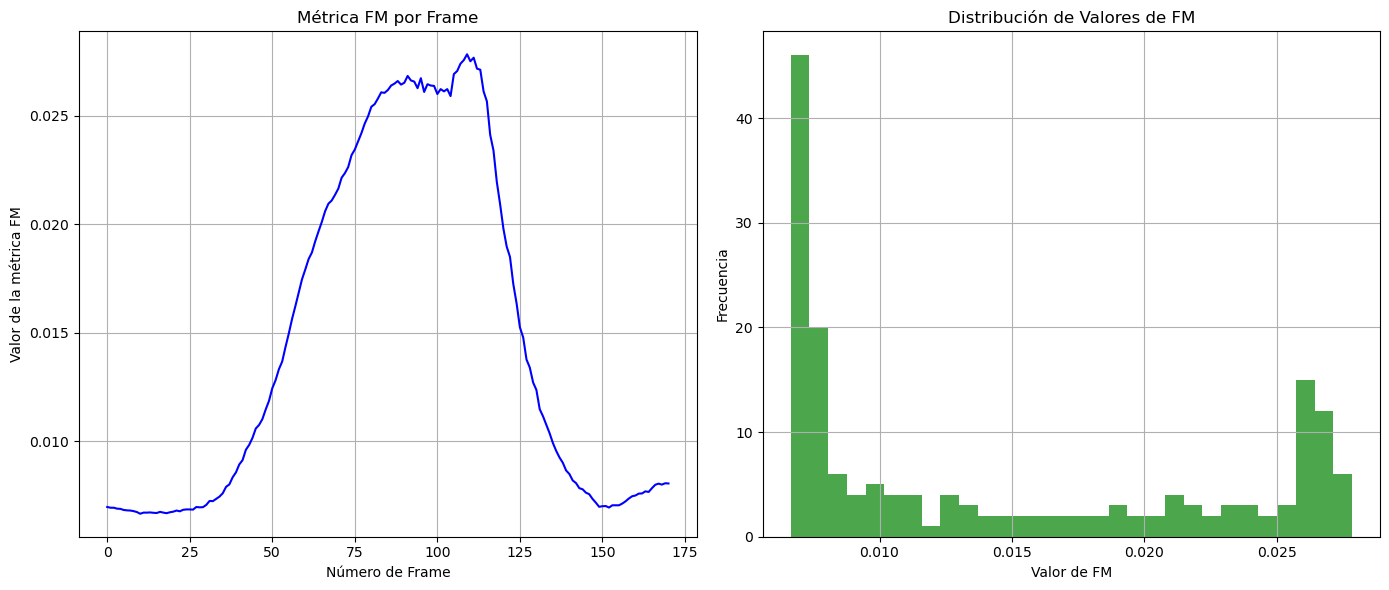

Frame más nítido: 109 (valor: 0.027843)
Frame más borroso: 10 (valor: 0.006645)
Nitidez promedio: 0.014648 ± 0.007948


In [135]:
print("Procesando video para calcular métricas de nitidez...")
sharpness_values, num_frames = process_video("focus_video.mov")

print(f"\nResultados del análisis de nitidez:")
print(f"Total de frames procesados: {num_frames}")

plot_results(sharpness_values)

#### Observaciones

- La curva obtenida muestra la evolución del valor de FM de modo que el FM es más algo cuando el pedal aparece en el video con máximo enfoque.

- El algoritmo automáticamente identifica el frame 109 como el frame con mayor FM.

En resumen:
- Cuando el pedal está fuera de foco, el FM es bajo.

- Cuando el pedal está mejor enfocado, FM aumenta.

     2) Medición sobre una ROI ubicada en el centro del frame. Área de la ROI = 5 o 10% del área total del frame

Funciones para calcular la ROI (region of interest) para la imagen en un porcentaje centrado de la imagen. Y para procesar el video en ROI.

In [136]:
def calculate_roi_measure(image, roi_percent=0.05):
    """
    Calcula la métrica de calidad en una ROI centrada.
    
    Args:
        image: Imagen en escala de grises
        roi_percent: Porcentaje del área total que ocupará la ROI (0.05 para 5%)
        
    Returns:
        float: Valor de la métrica para la ROI
    """
    height, width = image.shape
    roi_size = int(np.sqrt(roi_percent) * min(height, width))
    
    # Calcular coordenadas para centrar la ROI
    x_center, y_center = width // 2, height // 2
    half_size = roi_size // 2
    
    # Asegurarnos de que no nos salgamos de los límites
    x1 = max(0, x_center - half_size)
    y1 = max(0, y_center - half_size)
    x2 = min(width, x_center + half_size)
    y2 = min(height, y_center + half_size)
    
    # Extraer la ROI
    roi = image[y1:y2, x1:x2]
    
    # Calcular la métrica solo en la ROI
    return image_quality_measure(roi)

def process_video_roi(video_path, roi_percent=0.05):
    """
    Procesa un video para calcular la métrica en una ROI centrada.
    
    Args:
        video_path: Ruta al archivo de video
        roi_percent: Porcentaje del área total para la ROI (0.05 para 5%)
        
    Returns:
        tuple: (valores_medidos, num_frames)
    """
    cap = cv2.VideoCapture(video_path)
    measure_values = []
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    for _ in tqdm(range(frame_count), desc="Procesando frames (ROI)"):
        ret, frame = cap.read()
        if not ret:
            break
            
        # Convertir a escala de grises
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Calcular métrica solo en la ROI
        sharpness = calculate_roi_measure(gray, roi_percent)
        measure_values.append(sharpness)
    
    cap.release()
    return measure_values, frame_count

Ejemplo, ejecución y resultados

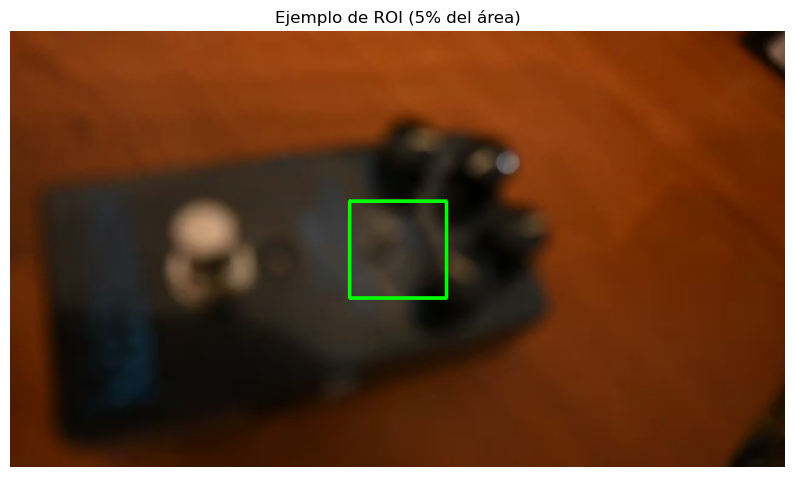

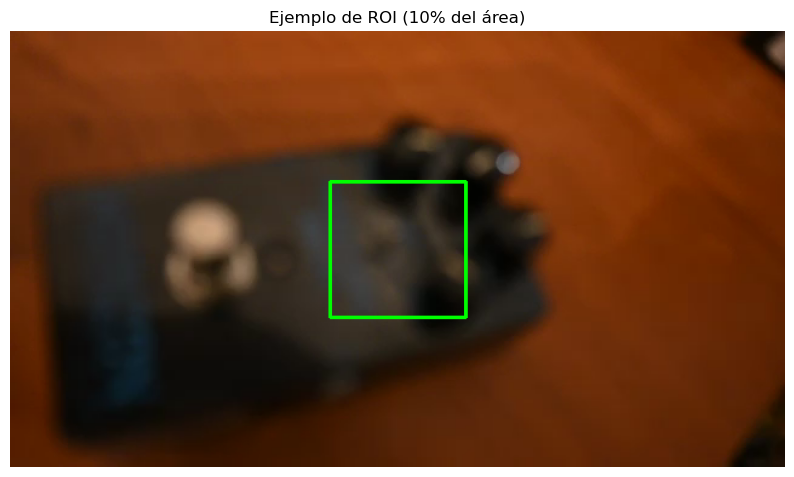


Procesando con ROI del 5%...


Procesando frames (ROI):   0%|          | 0/171 [00:00<?, ?it/s]


Procesando con ROI del 10%...


Procesando frames (ROI):   0%|          | 0/171 [00:00<?, ?it/s]

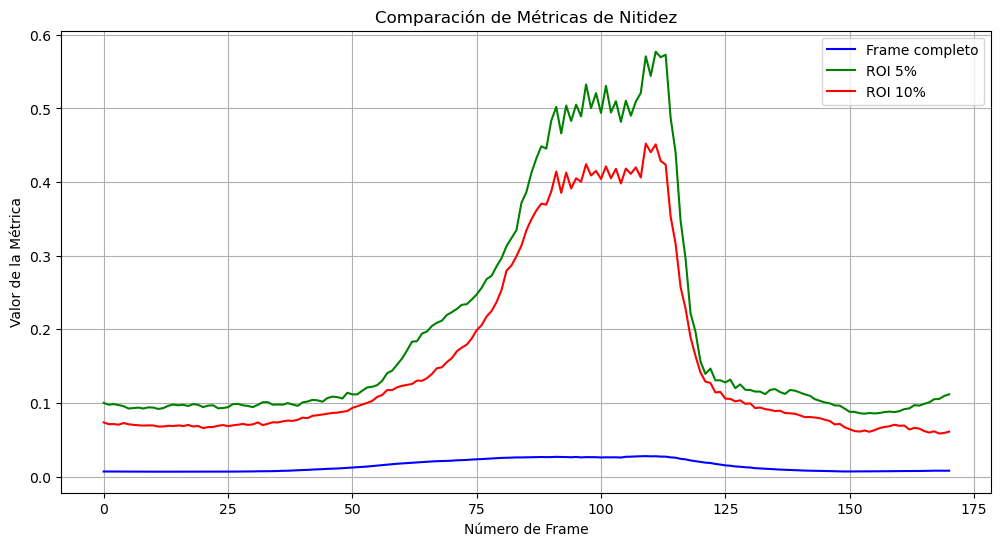


Frame completo:
  Frame más nítido: 109 (valor: 0.027843)
  Frame más borroso: 10 (valor: 0.006645)
  Valor promedio: 0.014648 ± 0.007948

ROI 5%:
  Frame más nítido: 111 (valor: 0.577031)
  Frame más borroso: 153 (valor: 0.085469)
  Valor promedio: 0.200049 ± 0.152464

ROI 10%:
  Frame más nítido: 109 (valor: 0.452328)
  Frame más borroso: 168 (valor: 0.058514)
  Valor promedio: 0.157190 ± 0.125169


In [137]:
def show_roi_example(frame, roi_percent=0.05):
    """
    Muestra un ejemplo de la ROI en un frame para orientación visual.
    """
    height, width = frame.shape[:2]
    roi_size = int(np.sqrt(roi_percent) * min(height, width))
    x_center, y_center = width // 2, height // 2
    half_size = roi_size // 2
    
    # Crear una copia para dibujar
    frame_copy = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    cv2.rectangle(frame_copy, 
                 (x_center - half_size, y_center - half_size),
                 (x_center + half_size, y_center + half_size),
                 (0, 255, 0), 2)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(frame_copy)
    plt.title(f"Ejemplo de ROI ({roi_percent*100:.0f}% del área)")
    plt.axis('off')
    plt.show()

# Cargar un frame de ejemplo para visualizar la ROI
cap = cv2.VideoCapture("focus_video.mov")
ret, example_frame = cap.read()
if ret:
    gray_frame = cv2.cvtColor(example_frame, cv2.COLOR_BGR2GRAY)
    show_roi_example(example_frame, 0.05)  # 5% del área
    show_roi_example(example_frame, 0.10)  # 10% del área
cap.release()

# Procesar el video con ROI del 5%
print("\nProcesando con ROI del 5%...")
roi_5_percent, _ = process_video_roi("focus_video.mov", 0.05)

# Procesar el video con ROI del 10%
print("\nProcesando con ROI del 10%...")
roi_10_percent, _ = process_video_roi("focus_video.mov", 0.10)

# Graficar resultados comparativos
plt.figure(figsize=(12, 6))
plt.plot(sharpness_values, 'b-', label='Frame completo')
plt.plot(roi_5_percent, 'g-', label='ROI 5%')
plt.plot(roi_10_percent, 'r-', label='ROI 10%')
plt.title('Comparación de Métricas de Nitidez')
plt.xlabel('Número de Frame')
plt.ylabel('Valor de la Métrica')
plt.legend()
plt.grid(True)
plt.show()

# Mostrar comparativas
def print_stats(data, label):
    max_idx = np.argmax(data)
    min_idx = np.argmin(data)
    print(f"\n{label}:")
    print(f"  Frame más nítido: {max_idx} (valor: {data[max_idx]:.6f})")
    print(f"  Frame más borroso: {min_idx} (valor: {data[min_idx]:.6f})")
    print(f"  Valor promedio: {np.mean(data):.6f} ± {np.std(data):.6f}")

print_stats(sharpness_values, "Frame completo")
print_stats(roi_5_percent, "ROI 5%")
print_stats(roi_10_percent, "ROI 10%")

     3) Medición sobre una matriz de enfoque compuesta por un arreglo de NxM elementos rectangulares equiespaciados. N y M son valores 
arbitrarios, probar con varios valores 3x3, 7x5, etc ... (al menos 3)

In [138]:
def calculate_grid_measure(image, grid_size=(3, 3)):
    """
    Calcula la métrica de calidad en una cuadrícula de regiones.
    
    Args:
        image: Imagen en escala de grises
        grid_size: Tupla (filas, columnas) que define la cuadrícula
        
    Returns:
        numpy.ndarray: Matriz con las métricas para cada región
        list: Lista plana de todas las métricas
    """
    height, width = image.shape
    rows, cols = grid_size
    
    # Tamaño de cada celda
    cell_height = height // rows
    cell_width = width // cols
    
    # Matriz para almacenar los resultados
    grid_metrics = np.zeros(grid_size)
    
    # Lista plana para el retorno
    all_metrics = []
    
    for i in range(rows):
        for j in range(cols):
            # Calcular límites de la celda actual
            y1 = i * cell_height
            y2 = (i + 1) * cell_height if i < rows - 1 else height
            x1 = j * cell_width
            x2 = (j + 1) * cell_width if j < cols - 1 else width
            
            # Extraer la celda
            cell = image[y1:y2, x1:x2]
            
            # Calcular métrica
            metric = image_quality_measure(cell)
            grid_metrics[i, j] = metric
            all_metrics.append(metric)
    
    return grid_metrics, all_metrics

def process_video_grid(video_path, grid_size=(3, 3)):
    """
    Procesa un video para calcular métricas en una cuadrícula.
    
    Args:
        video_path: Ruta al archivo de video
        grid_size: Tupla (filas, columnas) para la cuadrícula
        
    Returns:
        list: Lista de matrices de métricas por frame
        list: Lista de promedios por frame
    """
    cap = cv2.VideoCapture(video_path)
    all_grids = []
    frame_means = []
    
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    for _ in tqdm(range(frame_count), desc=f"Procesando {grid_size[0]}x{grid_size[1]}"):
        ret, frame = cap.read()
        if not ret:
            break
            
        # Convertir a escala de grises
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Calcular métricas en la cuadrícula
        grid_metrics, _ = calculate_grid_measure(gray, grid_size)
        all_grids.append(grid_metrics)
        frame_means.append(np.mean(grid_metrics))
    
    cap.release()
    return all_grids, frame_means

def plot_grid_evolution(metrics_list, grid_size, cell_pos=(0, 0)):
    """
    Muestra la evolución de la métrica para una celda específica a lo largo del tiempo.
    """
    rows, cols = grid_size
    i, j = cell_pos
    
    if i >= rows or j >= cols:
        print(f"Error: La posición {cell_pos} está fuera de los límites de la cuadrícula {grid_size}.")
        return
    
    # Extraer valores para la celda (i,j) de cada frame
    cell_values = [metrics[i, j] for metrics in metrics_list]
    
    plt.figure(figsize=(12, 4))
    plt.plot(cell_values, 'b-')
    plt.title(f'Evolución de la métrica en la celda ({i},{j})')
    plt.xlabel('Número de Frame')
    plt.ylabel('Valor de la Métrica')
    plt.grid(True)
    plt.show()

Ejecución y resultados:


Procesando con cuadrícula 3x3...


Procesando 3x3:   0%|          | 0/171 [00:00<?, ?it/s]


Procesando con cuadrícula 5x3...


Procesando 5x3:   0%|          | 0/171 [00:00<?, ?it/s]


Procesando con cuadrícula 7x5...


Procesando 7x5:   0%|          | 0/171 [00:00<?, ?it/s]

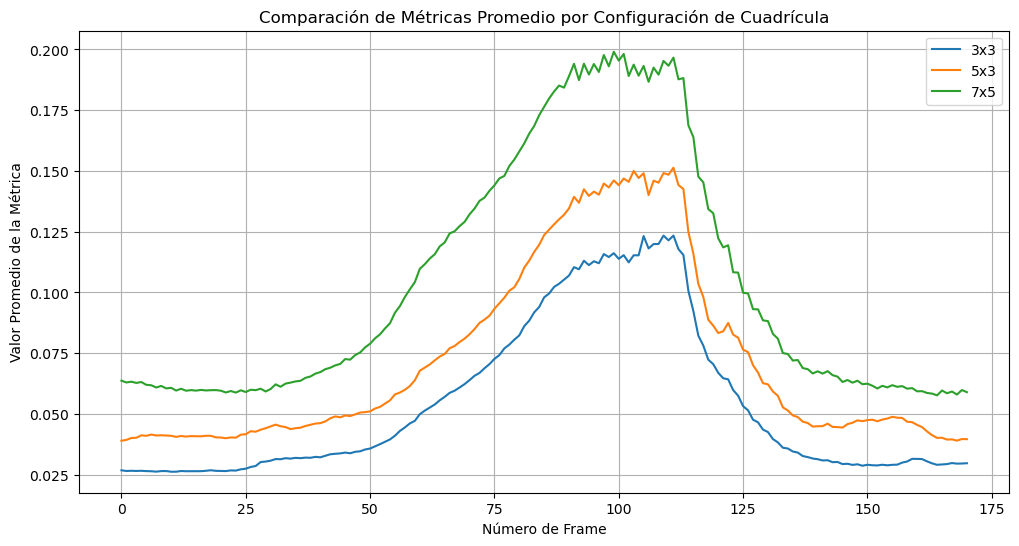


Estadísticas Comparativas:

Cuadrícula 3x3:
  Frame con mejor enfoque promedio: 111 (valor: 0.123394)
  Rango de valores: 0.026240 - 0.123394
  Media: 0.053906 ± 0.031878

Cuadrícula 5x3:
  Frame con mejor enfoque promedio: 111 (valor: 0.151318)
  Rango de valores: 0.038990 - 0.151318
  Media: 0.072283 ± 0.036966

Cuadrícula 7x5:
  Frame con mejor enfoque promedio: 99 (valor: 0.199048)
  Rango de valores: 0.057661 - 0.199048
  Media: 0.103236 ± 0.049621


In [139]:
# Configuraciones de cuadrícula a probar
GRID_CONFIGS = [
    (3, 3),  # 3x3
    (5, 3),  # 5x3
    (7, 5),  # 7x5
]

# Procesar el video con cada configuración de cuadrícula
results = {}
for grid_size in GRID_CONFIGS:
    print(f"\nProcesando con cuadrícula {grid_size[0]}x{grid_size[1]}...")
    all_grids, frame_means = process_video_grid("focus_video.mov", grid_size)
    results[grid_size] = {
        'all_grids': all_grids,
        'frame_means': frame_means
    }

# Comparar promedios de todas las configuraciones
plt.figure(figsize=(12, 6))
for grid_size, data in results.items():
    plt.plot(data['frame_means'], label=f'{grid_size[0]}x{grid_size[1]}')

plt.title('Comparación de Métricas Promedio por Configuración de Cuadrícula')
plt.xlabel('Número de Frame')
plt.ylabel('Valor Promedio de la Métrica')
plt.legend()
plt.grid(True)
plt.show()

# Mostrar estadísticas comparativas
print("\nEstadísticas Comparativas:")
for grid_size, data in results.items():
    means = data['frame_means']
    max_idx = np.argmax(means)
    print(f"\nCuadrícula {grid_size[0]}x{grid_size[1]}:")
    print(f"  Frame con mejor enfoque promedio: {max_idx} (valor: {means[max_idx]:.6f})")
    print(f"  Rango de valores: {np.min(means):.6f} - {np.max(means):.6f}")
    print(f"  Media: {np.mean(means):.6f} ± {np.std(means):.6f}")

Procesando video con métrica de varianza del Laplaciano...


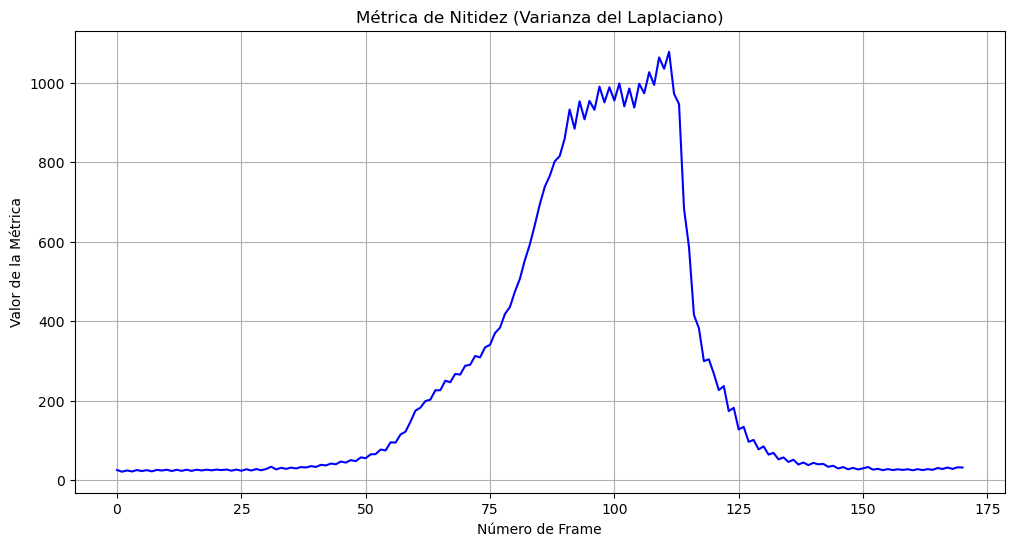

Frame más nítido: 111 (valor: 1077.71)
Frame más borroso: 1 (valor: 21.02)
Rango de valores: 21.02 - 1077.71
Media: 255.58 ± 337.16


In [140]:
def laplacian_variance_measure(image, ksize=3):
    """
    Calcula la métrica de enfoque basada en la varianza del Laplaciano.
    
    Args:
        image: Imagen en escala de grises (numpy array)
        ksize: Tamaño del kernel del Laplaciano (debe ser positivo e impar)
        
    Returns:
        float: Medida de nitidez basada en la varianza del Laplaciano
    """
    # Calcular el Laplaciano de la imagen
    laplacian = cv2.Laplacian(image, cv2.CV_64F, ksize=ksize)
    
    # Calcular la varianza del Laplaciano
    return laplacian.var()

def process_video_with_laplacian(video_path, ksize=3):
    """
    Procesa un video completo calculando la métrica de varianza del Laplaciano.
    
    Args:
        video_path: Ruta al archivo de video
        ksize: Tamaño del kernel del Laplaciano
        
    Returns:
        list: Lista de valores de nitidez por frame
    """
    cap = cv2.VideoCapture(video_path)
    sharpness_values = []
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        # Convertir a escala de grises
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Calcular métrica de nitidez
        sharpness = laplacian_variance_measure(gray, ksize)
        sharpness_values.append(sharpness)
    
    cap.release()
    return sharpness_values

# Ejemplo de uso
print("Procesando video con métrica de varianza del Laplaciano...")
laplacian_sharpness = process_video_with_laplacian("focus_video.mov", ksize=3)

# Graficar resultados
plt.figure(figsize=(12, 6))
plt.plot(laplacian_sharpness, 'b-')
plt.title('Métrica de Nitidez (Varianza del Laplaciano)')
plt.xlabel('Número de Frame')
plt.ylabel('Valor de la Métrica')
plt.grid(True)
plt.show()

# Mostrar estadísticas
max_idx = np.argmax(laplacian_sharpness)
min_idx = np.argmin(laplacian_sharpness)
print(f"Frame más nítido: {max_idx} (valor: {laplacian_sharpness[max_idx]:.2f})")
print(f"Frame más borroso: {min_idx} (valor: {laplacian_sharpness[min_idx]:.2f})")
print(f"Rango de valores: {np.min(laplacian_sharpness):.2f} - {np.max(laplacian_sharpness):.2f}")
print(f"Media: {np.mean(laplacian_sharpness):.2f} ± {np.std(laplacian_sharpness):.2f}")

In [141]:
def compare_metrics(freq_vals, lap_vals):
    # Normalización para superponer escalas
    freq_norm = (freq_vals - np.min(freq_vals)) / (np.max(freq_vals) - np.min(freq_vals))
    lap_norm =  (lap_vals - np.min(lap_vals)) / (np.max(lap_vals) - np.min(lap_vals))

    plt.figure(figsize=(14, 6))
    plt.plot(freq_norm, label="Frecuencial (FM)", linewidth=2)
    plt.plot(lap_norm, label="Laplaciana", linewidth=2)
    plt.title("Comparación de Métricas de Enfoque (escaladas)")
    plt.xlabel("Número de Frame")
    plt.ylabel("Métrica Normalizada")
    plt.grid(True)
    plt.legend()
    plt.show()

    # reporte de frames detectados
    print(f"FM detecta máximo enfoque en frame: {np.argmax(freq_vals)}")
    print(f"Tenengrad detecta máximo enfoque en frame: {np.argmax(lap_vals)}")


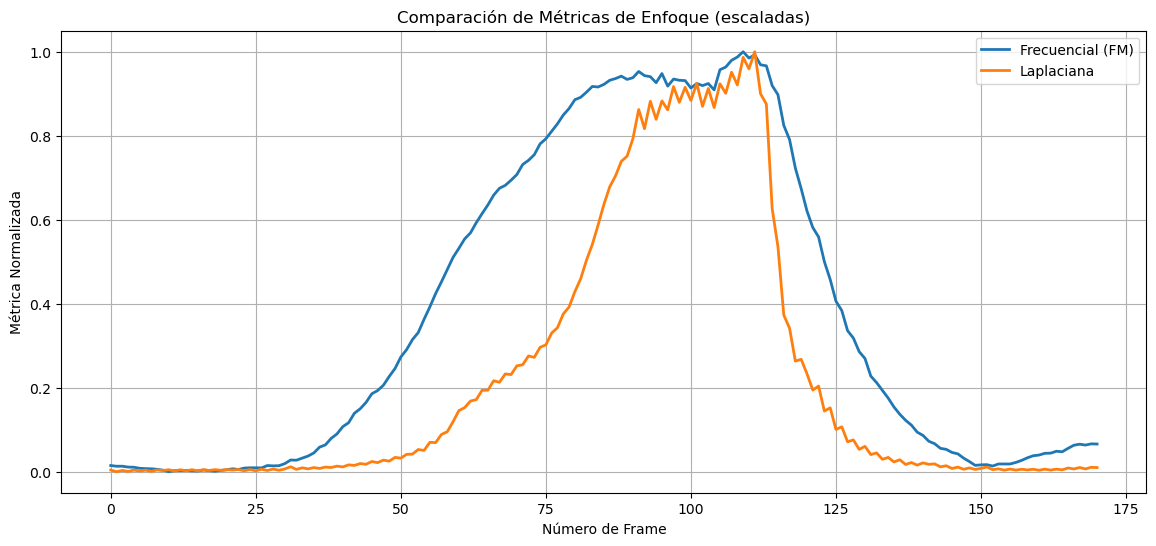

FM detecta máximo enfoque en frame: 109
Tenengrad detecta máximo enfoque en frame: 111


In [142]:
compare_metrics(sharpness_values, laplacian_sharpness)